In [303]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sps
from scipy.ndimage import gaussian_filter
from sklearn.feature_selection import mutual_info_regression as mi_skl
import seaborn as sns
from scipy import stats
import time
from matplotlib import gridspec
import os
from scipy.spatial import distance
import itertools
import matplotlib.patches as patches
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'


# data
animals = [ 'H2224', 'H2225','H2226', 'H2230', 'H2231','H2234', 'H2235', 'H2241'] #  'H2222',

phases = ["P1Allo", "P1Ego", "P2Ego", "P2Allo"]

phase_map= {
     'H2222': {1: 'Ego', 2: 'Allo'},
     'H2224': {1: 'Ego', 2: 'Allo'},
     'H2225': {1: 'Allo', 2: 'Ego'},
     'H2226': {1: 'Allo', 2: 'Ego'},
     'H2230': {1: 'Allo', 2: 'Ego'},
     'H2231': {1: 'Ego', 2: 'Allo'},
     'H2234': {1: 'Allo', 2: 'Ego'},
     'H2235': {1: 'Ego', 2: 'Allo'},
     'H2241': {1: 'Allo', 2: 'Ego'}}

#-------------------------------------------------------------------------------------------

#File paths - adapt to local situation

SaveTo2 = r'C:\Users\fgobbo\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Event Frequency SB' #Where to save figures

#pcDIR = homeDir + "Data/Place cell meta/" # where place cell table is saved

template = r'C:\Users\fgobbo\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Data\%s\%s\ALIGNED TRA EVE\REGISTERED\Events\Quality_checked'


#Split up the arena <<-------- adapt to new version
def arena_binned(x, y, xdim, ydim, pix_cm, pf_cm):
    d_x = xdim[0] - xdim[1] # xdim[0] = max, xdim[1] = min
    d_y = ydim[0] - ydim[1] # ydim[0] = max, ydim[1] = min
    nBnx = int((d_x/(pix_cm*pf_cm)))
    nBny = int((d_y/(pix_cm*pf_cm)))
    bn_x = [int(i) for i in np.linspace(xdim[0],xdim[1],nBnx)]
    bn_y = [int(i) for i in np.linspace(ydim[0], ydim[1],nBny)]

    bx = ((x-bn_x[0])/(bn_x[1]-bn_x[0])).astype(int)
    by = ((y-bn_y[0])/(bn_y[1]-bn_y[0])).astype(int)
#     bx[bx>=20] = 19
#     by[by>=20] = 19
    S = np.vstack((bx,by))
    print(np.max(S))
    linS = np.ravel_multi_index(S,(nBnx,nBny))
    occMap = sps.csr_matrix((np.ones(len(bx)),(bx,by)),shape=(nBnx,nBny),dtype=float).todense()
    return linS.astype(float), occMap, nBnx, nBny, bx, by

#ARENA 2.0 parameters
xdim = [900, -100] # Set arena x dimensions (northwest - (-20,-20), 320x320)
ydim = [900,-100] # Set Arena y dimensions
pix_cm = 5.2 # Set how many pixels = 1 cm
pf_cm = 10 # Set bin size for place field (cms)
occplot = False
cell_type = 1

def add_arena_details(ax, sw_x, sw_y, SWS, bl_x, bl_y, w_x, w_y, pix_cm, map_shape):
    """Plot arena features scaled to place-map bin coordinates"""

    # map dimensions in bins
    nx, ny = map_shape

    # scaling factors: cm → bins
    scale_x = nx / ((w_x +200) / (pf_cm))
    scale_y = ny / ((w_y+200) / (pf_cm))

    # scale SWS coordinates
    sw_x_bins = (sw_x - bl_x) * scale_x / (pf_cm)+1.5
    sw_y_bins = (sw_y - bl_y) * scale_y / (pf_cm)+1.5

    ax.scatter(sw_x_bins, sw_y_bins, c=None, s=130, alpha=0.3, edgecolors='k')

    # scale SWS labels
    for i in range(1, 7):
        x = (SWS[i][0] - bl_x) * scale_x / (pf_cm)+1.5
        y = (SWS[i][1] - bl_y) * scale_y / (pf_cm)+1.5
        ax.text(x, y, i, ha="center", va="center", fontsize=10)

    # scale arena rectangle
    rect_x = (bl_x - bl_x) * scale_x +1.5
    rect_y = (bl_y - bl_y) * scale_y+ 1.5
    rect_w = w_x * scale_x / (pf_cm)
    rect_h = w_y * scale_y / (pf_cm)

    rect = patches.Rectangle((rect_x, rect_y), rect_w, rect_h,
                             linewidth=0.2, edgecolor='k', facecolor='none')
    ax.add_patch(rect)

    return



def sw_naming(sw_x, sw_y):
    """Names each of the six sandwells based on the SW coordinate input"""
    sw_xord = np.array(sorted(sw_x.copy()))
    sw_yord = np.array(sorted(sw_y.copy()))
    for i in range(6):
        if sw_x[i] in sw_xord[:2] and sw_y[i] in sw_yord[:2]:
            SW1 = [sw_x[i], sw_y[i]]
        elif sw_x[i] in sw_xord[-2:] and sw_y[i] in sw_yord[:2]:
            SW2 = [sw_x[i], sw_y[i]]
        elif sw_x[i] in sw_xord[:2] and sw_y[i] in sw_yord[-2:]:
            SW5 = [sw_x[i], sw_y[i]]
        elif sw_x[i] in sw_xord[-2:] and sw_y[i] in sw_yord[-2:]:
            SW6 = [sw_x[i], sw_y[i]]
        elif sw_x[i] - sw_xord[0] < sw_xord[-1] - sw_x[i]:
            SW3 = [sw_x[i], sw_y[i]]
        else:
            SW4 = [sw_x[i], sw_y[i]]
    return {1:SW1, 2:SW2, 3:SW3, 4:SW4, 5:SW5, 6:SW6}

SWS={6: [np.int64(140), np.int64(145)],
     5: [np.int64(560), np.int64(139)],
     4: [np.int64(244), np.int64(351)],
     3: [np.int64(460), np.int64(349)],
     2: [np.int64(144), np.int64(563)],
     1: [np.int64(564), np.int64(559)]}

sw_x=np.array([460, 560, 564, 244, 140, 144]); sw_y= np.array([349, 139, 559, 351, 145, 563])
bl_x = np.int64(0); bl_y = np.int64(0)
tr_x = np.int64(701); tr_y = np.int64(705)
w_x = np.int64(701); w_y = np.int64(705)
cxn_x = np.int64(356); cxn_y = np.int64(163)

In [ ]:
# =========================================================
# GLOBAL SETTINGS
# =========================================================

DT = 1 / 20  # 20 Hz → 0.05 seconds per frame
F_START = 0
F_END = 200
BIN_SIZE = 10


# =========================================================
# FANO FACTOR
# =========================================================

def fano_factor(event_times, f_start=F_START, f_end=F_END, bin_size=BIN_SIZE):
    event_times = np.asarray(event_times)
    
    bins = np.arange(f_start, f_end + bin_size, bin_size)
    counts, _ = np.histogram(event_times, bins=bins)
    
    if len(counts) < 2:
        return np.nan, counts
    
    mean_count = counts.mean()
    var_count = counts.var(ddof=1)
    
    fano = var_count / mean_count if mean_count > 0 else np.nan
    return fano, counts


def fano_shuffle(event_times, f_start=F_START, f_end=F_END, bin_size=BIN_SIZE, n_shuffles=1000):
    event_times = np.asarray(event_times)
    n_spikes = len(event_times)
    
    if n_spikes == 0:
        return np.full(n_shuffles, np.nan)
    
    shuffled_fanos = []
    
    for _ in range(n_shuffles):
        shuffled = np.random.uniform(f_start, f_end, n_spikes)
        fano, _ = fano_factor(shuffled, f_start, f_end, bin_size)
        shuffled_fanos.append(fano)
    
    return np.array(shuffled_fanos)


def compute_fano_stats(event_times, n_shuffles=1000):
    real_fano, _ = fano_factor(event_times)
    shuffled_fanos = fano_shuffle(event_times, n_shuffles=n_shuffles)
    
    valid = ~np.isnan(shuffled_fanos)
    
    if np.isnan(real_fano) or not np.any(valid):
        return real_fano, shuffled_fanos, np.nan
    
    shuffled_mean = np.nanmean(shuffled_fanos)
    
    p_value = np.mean(
        np.abs(shuffled_fanos[valid] - shuffled_mean) >= 
        np.abs(real_fano - shuffled_mean)
    )
    
    return real_fano, shuffled_fanos, p_value


# =========================================================
# ISI ANALYSIS (IN SECONDS)
# =========================================================

def compute_isi(event_times, dt=DT):
    event_times = np.sort(np.asarray(event_times))
    
    if len(event_times) < 2:
        return np.array([])
    
    return np.diff(event_times) * dt  # convert to seconds


def isi_cv(isis):
    if len(isis) < 2 or np.mean(isis) == 0:
        return np.nan
    
    return np.std(isis, ddof=1) / np.mean(isis)


def shuffle_isi(event_times, f_start=F_START, f_end=F_END, dt=DT, n_shuffles=500):
    event_times = np.asarray(event_times)
    n_spikes = len(event_times)
    
    if n_spikes < 2:
        return [np.array([])] * n_shuffles
    
    shuffled_isis = []
    
    for _ in range(n_shuffles):
        shuffled = np.random.uniform(f_start, f_end, n_spikes)
        isis = np.diff(np.sort(shuffled)) * dt
        shuffled_isis.append(isis)
    
    return shuffled_isis


def compute_isi_stats(event_times, n_shuffles=500):
    real_isis = compute_isi(event_times)
    shuffled_isis = shuffle_isi(event_times, n_shuffles=n_shuffles)
    
    real_cv = isi_cv(real_isis)
    shuffled_cvs = np.array([isi_cv(s) for s in shuffled_isis])
    
    valid = ~np.isnan(shuffled_cvs)
    
    if np.isnan(real_cv) or not np.any(valid):
        return real_cv, shuffled_cvs, np.nan, real_isis, shuffled_isis
    
    shuffled_mean = np.nanmean(shuffled_cvs)
    
    p_value = np.mean(
        np.abs(shuffled_cvs[valid] - shuffled_mean) >= 
        np.abs(real_cv - shuffled_mean)
    )
    
    return real_cv, shuffled_cvs, p_value, real_isis, shuffled_isis


# =========================================================
# OPTIONAL PLOTTING
# =========================================================

def plot_fano(real_fano, shuffled_fanos):
    plt.figure()
    plt.hist(shuffled_fanos[~np.isnan(shuffled_fanos)], bins=30, alpha=0.7, label="Shuffled")
    plt.axvline(real_fano, linestyle='dashed', linewidth=2, label="Real")
    plt.xlabel("Fano factor")
    plt.ylabel("Count")
    plt.legend()
    plt.title("Fano Shuffle Comparison")
    plt.show()


def plot_isi(real_isis, shuffled_isis):
    valid = [s for s in shuffled_isis if len(s) > 0]
    
    shuffled_all = np.concatenate(valid) if len(valid) > 0 else np.array([])
    
    plt.figure()
    
    if len(real_isis) > 0:
        plt.hist(real_isis, bins=50, density=True, alpha=0.6, label="Real")
    
    if len(shuffled_all) > 0:
        plt.hist(shuffled_all, bins=50, density=True, alpha=0.6, label="Shuffled")
    
    plt.xlabel("ISI (seconds)")
    plt.ylabel("Density")
    plt.legend()
    plt.title("ISI Distribution")
    plt.show()

In [386]:
import inspect
print(inspect.getsource(shuffle_isi))

def shuffle_isi(event_times, f_start=F_START, f_end=F_END, dt=DT, n_shuffles=500):
    event_times = np.asarray(event_times)
    n_spikes = len(event_times)
    
    if n_spikes < 2:
        return [np.array([])] * n_shuffles
    
    shuffled_isis = []
    
    for _ in range(n_shuffles):
        shuffled = np.random.uniform(f_start, f_end, n_spikes)
        isis = np.diff(np.sort(shuffled)) * dt
        shuffled_isis.append(isis)
    
    return shuffled_isis



In [304]:
import warnings
warnings.filterwarnings("ignore")

In [305]:
def compute_full_metrics(event_times):
    
    # ---------------- FANO ----------------
    real_fano, shuffled_fanos, fano_p = compute_fano_stats(event_times)
    
    # ---------------- ISI ----------------
    real_cv, shuffled_cvs, isi_p, real_isis, shuffled_isis = compute_isi_stats(event_times)
    
    return (
        real_fano,
        shuffled_fanos,
        fano_p,
        real_cv,
        shuffled_cvs,
        isi_p,
        real_isis,
        shuffled_isis
    )


# =========================================================
# APPLY FUNCTION TO DATAFRAME COLUMN
# =========================================================

def apply_metrics(df, col, prefix):
    
    results = df[col].apply(compute_full_metrics)
    
    df[f"{prefix}_real_fano"] = results.apply(lambda x: x[0])
    df[f"{prefix}_shuffled_fanos"] = results.apply(lambda x: x[1])
    df[f"{prefix}_fano_p"] = results.apply(lambda x: x[2])
    
    df[f"{prefix}_real_cv"] = results.apply(lambda x: x[3])
    df[f"{prefix}_shuffled_cvs"] = results.apply(lambda x: x[4])
    df[f"{prefix}_isi_p"] = results.apply(lambda x: x[5])
    
    df[f"{prefix}_real_isis"] = results.apply(lambda x: x[6])
    df[f"{prefix}_shuffled_isis"] = results.apply(lambda x: x[7])
    
    return df



In [306]:
folder_annot=r'C:\Users\fgobbo\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Figures\Preplay\Startbox_cells\Annotation\Analysed\CSV'

df_annot=pd.DataFrame()

for folder, subfolder, files in os.walk(folder_annot):
    for file in files:
        print(file)
        df_i=pd.read_csv(os.path.join(folder, file))
        animal, phase, fg= file.split('_')

        df_i=df_i[['Animal', 'Type', 'Session', 'Stage', 'Trial', 'Correct/Incorrect', 'Direct','Start Box', 'Reward well',  'Path']]
        df_i = df_i.rename(columns={"Type": "EA"})
        df_i = df_i.drop_duplicates().reset_index(drop=True)
        df_annot=pd.concat([df_annot, df_i]).reset_index(drop=True)
        
df_annot["First_visited_SW"] = (df_annot["Path"].astype(str).str.extract(r"(\d)").astype(int))
df_annot["Session"] = (df_annot["Session"].astype(str).str.extract(r"(\d{2})$").astype(int))

df_annot["Trial"] = df_annot["Trial"].astype(float)


H2222_P1Ego_FG.csv
H2224_P1Ego_FG.csv
H2224_P2Allo_FG.csv
H2225_P1Allo_FG.csv
H2225_P2Ego_FG.csv
H2226_P1Allo_FG.csv
H2226_P2Ego_FG.csv
H2230_P1Allo_FG.csv
H2230_P2Ego_FG.csv
H2231_P1Ego_FG.csv
H2231_P2Allo_FG.csv
H2234_P1Allo_FG.csv
H2234_P2Ego_FG.csv
H2235_P1Ego_FG.csv
H2241_P1Allo_FG.csv
H2241_P2Ego_FG.csv


In [307]:
df_annot

,Animal,EA,Session,Stage,Trial,Correct/Incorrect,Direct,Start Box,Reward well,Path,First_visited_SW
0,H2222,E,28,SAM,1.0,Incorrect,N,E,5,2135,2
1,H2222,E,28,SAM,2.0,Correct,Y,E,5,45,4
2,H2222,E,28,SAM,3.0,Correct,Y,E,5,45,4
3,H2222,E,28,SAM,4.0,Correct,Y,E,5,5,5
4,H2222,E,30,CHO,3.0,Correct,Y,S,6,6,6
...,...,...,...,...,...,...,...,...,...,...,...
1344,H2241,E,34,CHO,3.0,Correct,Y,E,1,1,1
1345,H2241,E,34,CHO,4.0,Correct,Y,E,1,1,1
1346,H2241,E,34,CHO,5.0,Correct,Y,E,1,1,1
1347,H2241,E,34,CHO,6.0,Correct,Y,E,1,1,1


animals =['H2226']
phases = ['P2Ego']

Processing  H2224 P1Allo ............
Processing  H2224 P1Ego ............
16


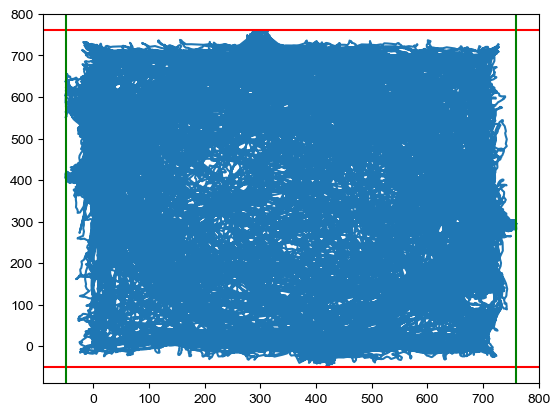

Processing  H2224 P2Ego ............
Processing  H2224 P2Allo ............
16


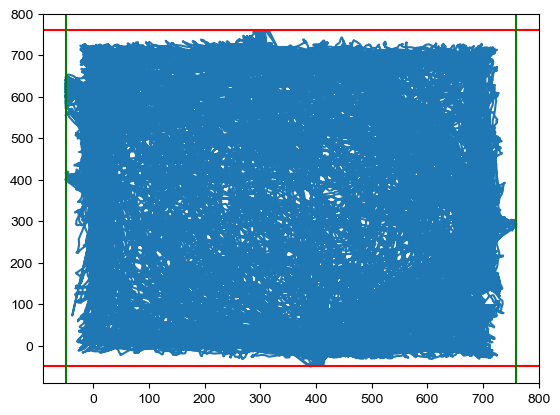

Processing  H2225 P1Allo ............
16


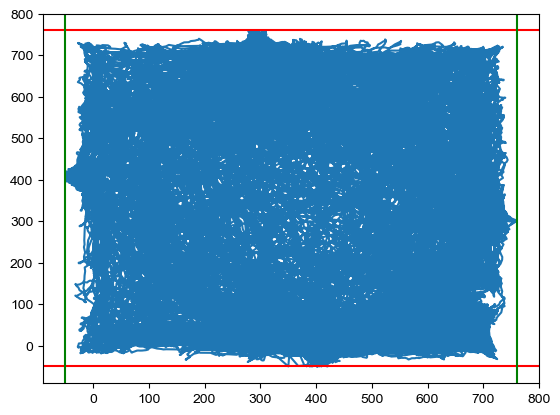

Processing  H2225 P1Ego ............
Processing  H2225 P2Ego ............
16


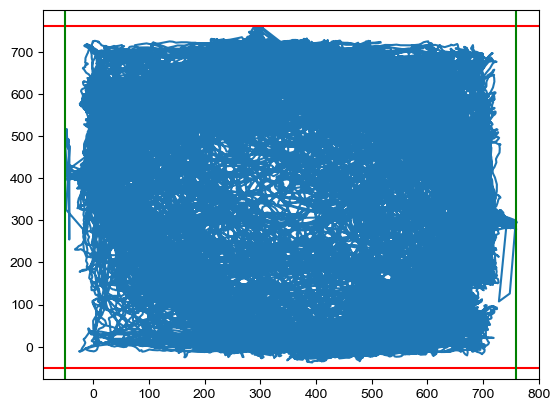

Processing  H2225 P2Allo ............
Processing  H2226 P1Allo ............
16


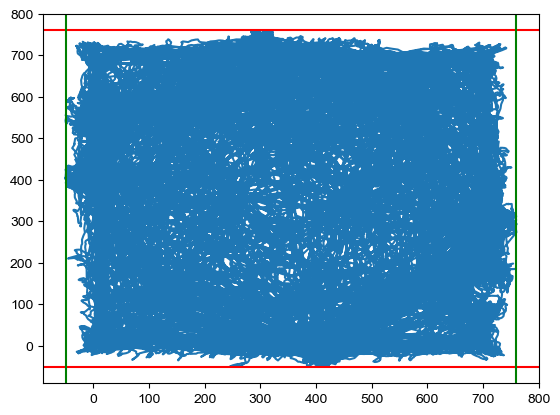

Processing  H2226 P1Ego ............
Processing  H2226 P2Ego ............
16


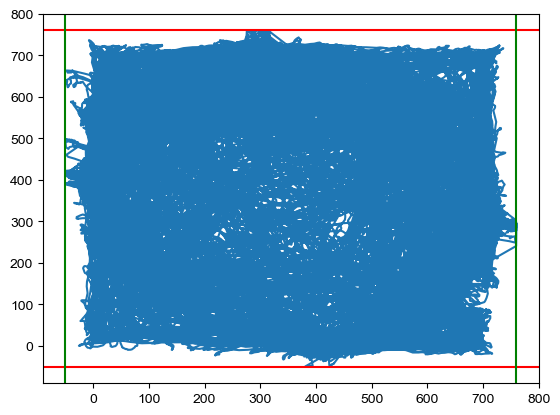

Processing  H2226 P2Allo ............
Processing  H2230 P1Allo ............
16


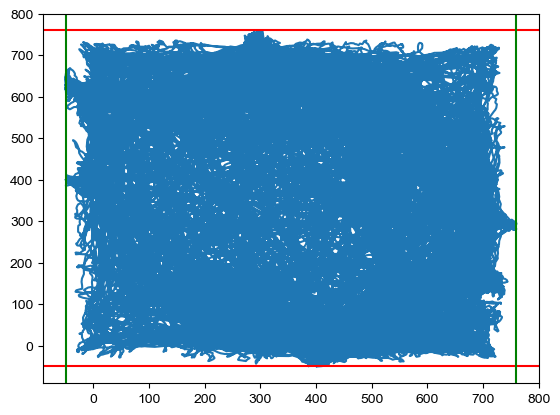

Processing  H2230 P1Ego ............
Processing  H2230 P2Ego ............
16


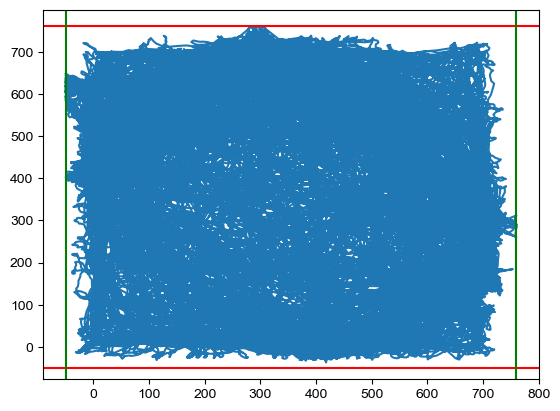

Processing  H2230 P2Allo ............
Processing  H2231 P1Allo ............
Processing  H2231 P1Ego ............
16


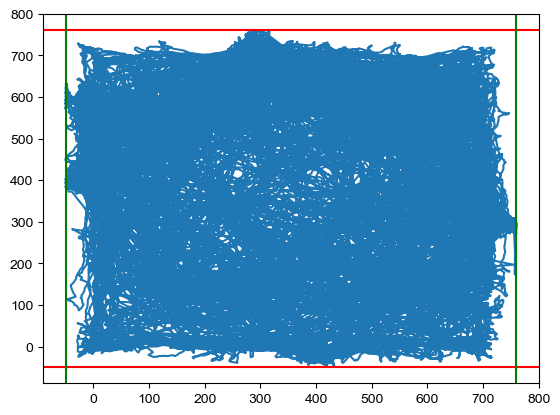

Processing  H2231 P2Ego ............
Processing  H2231 P2Allo ............
16


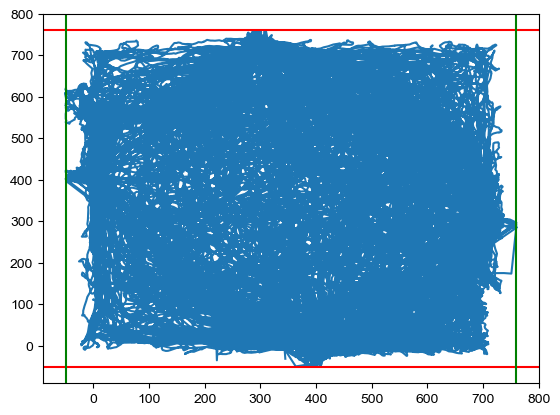

Processing  H2234 P1Allo ............
16


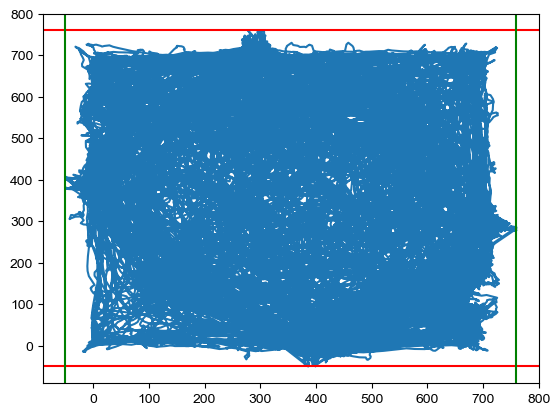

Processing  H2234 P1Ego ............
Processing  H2234 P2Ego ............
16


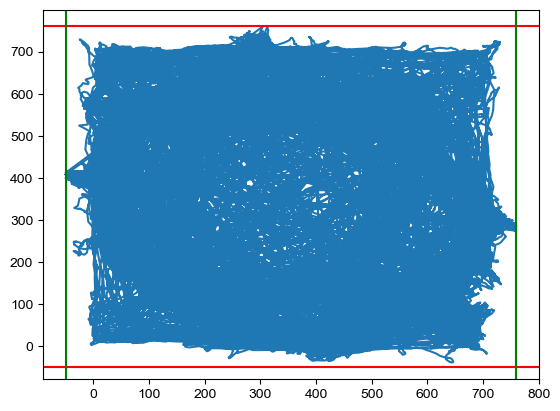

Processing  H2234 P2Allo ............
Processing  H2235 P1Allo ............
Processing  H2235 P1Ego ............
16


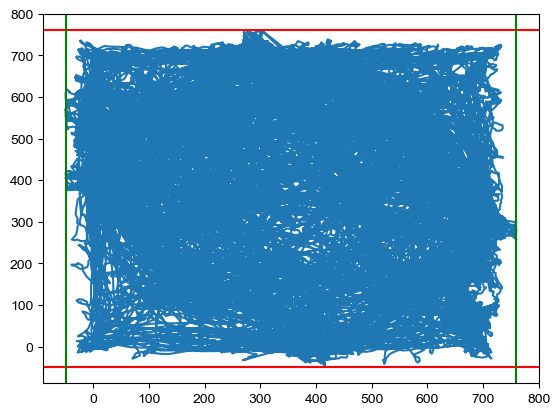

Processing  H2235 P2Ego ............
Processing  H2235 P2Allo ............
Processing  H2241 P1Allo ............
16


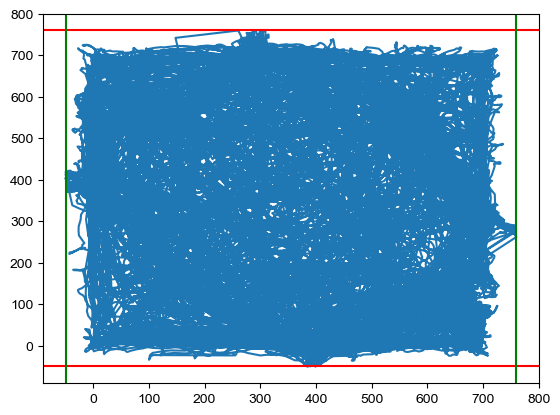

Processing  H2241 P1Ego ............
Processing  H2241 P2Ego ............
16


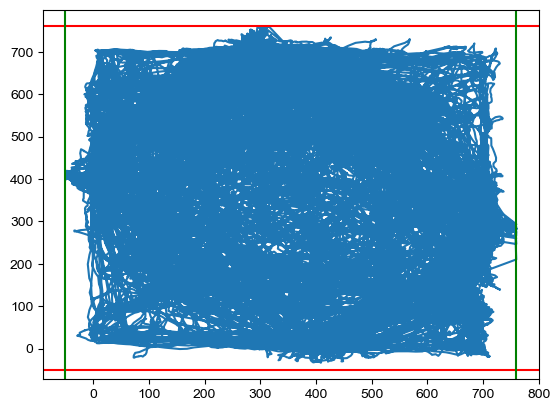

Processing  H2241 P2Allo ............


In [308]:
occplot=True

df_all_animals_all_phases=pd.DataFrame()

for animal, phase in itertools.product(animals, phases):

        print('Processing ', animal, phase, "............")
        # -------------------------------------------------------------
        # LOOK INTO THE EXP OF CELLS TO DEFINE BASELINE FIRING RATE
        # -------------------------------------------------------------
    
        folder = template % (animal, phase)
    
        if not os.path.isdir(folder):
            continue
        
        df_pre = pd.DataFrame() # This will contain events from all PRE files
    
        df_cells=pd.DataFrame() # This will contain EXP activity
    
        # --------------------------------------------
        # Iterate on PRE files inside folder
        # --------------------------------------------
    
        for file in os.listdir(folder):
            if file[-14:]!='all_trials.csv':
    
                full_path = os.path.join(folder, file)
                animal, session, stage, eve, dlc=file.split('_')
        
                if stage[:3]=='PRE':
                    df_i = pd.read_csv(full_path)
                
                    df_i["Animal"] = animal
                    df_i["Phase"] = float(phase[1:2])
                    df_i["EA"] = session[0]
                    df_i["Session"] = session[1:]
                    df_i["Recording"] = stage
                    
                    """merged_cols = df_pre.columns.intersection(df_i.columns)
                    num_merged = len(merged_cols)
                    print("Merged columns:", list(merged_cols))
                    print("Number of merged columns:", num_merged)"""
    
                    
                    df_pre = pd.concat([df_pre, df_i]).reset_index(drop=True)
    
    
    
        #Extract x,y actvity 
        x = df_pre['cap_x'].values; y = df_pre['cap_y'].values 
    
        df_pre["Estimated_Position"] = np.where(
            (df_pre["cap_x"].between(-50, 760)) & (df_pre["cap_y"].between(-50, 760)),
            "arena",
            "outside"
        )
        
        df_pre=df_pre[df_pre['Estimated_Position']=='arena']
        
        EXP_x = df_pre['cap_x'].values; EXP_y = df_pre['cap_y'].values 
        
        EXPlinS, EXPoccMap, EXPnBnx, EXPnBny, EXPbx, EXPby = arena_binned(x = EXP_x, y = EXP_y, xdim = xdim, ydim = ydim, pix_cm = pix_cm, pf_cm = pf_cm)
        
        EXPocc_nan = np.argwhere(EXPoccMap == 0)
        
    
        plt.plot(df_pre.cap_x, df_pre.cap_y)
        plt.axhline(y=760, c='r')
        plt.axhline(y=-50, c='r')
        plt.axvline(x=760, c='g')
        plt.axvline(x=-50, c='g')
        plt.show()
    
    
        #Exclude cells that do not fire at all
           
        EXPmov = (df_pre['Movement status']=='moving') & \
                 (df_pre['Estimated_Position']=='arena')
        
        # Select EXP columns
        EXP_cells = df_pre[[i for i in df_pre.columns if i.startswith(' C')]]
        
        # Filter active EXP cells
        EXP_cells = [i for i in EXP_cells.columns if EXP_cells.loc[EXPmov, i].sum() > 1]
        
        
        for cell in EXP_cells:
                #Isolate events per stage
                EXP_ev = df_pre[cell].values; #EXP_ev[EXPsta]=0
                
                # OPTIONAL: Binarized event
                EXP_ev[EXP_ev > 0] = 1 
        
                # Calculate event frequency in PRE excluding NaNs
                n_events_exp=np.nansum(EXP_ev)
                EXP_ev_len=np.sum(~np.isnan(EXP_ev))
                events_per_min_exp=n_events_exp/(EXP_ev_len/20 /60)
        
                #Calculate rate and place map for EXP
                #Convert NaNs into 0s for the map calculation
    
                EXP_ev = np.nan_to_num(EXP_ev, nan=0.0) 
            
                EXPrateMap = sps.csr_matrix((EXP_ev,(EXPbx,EXPby)),shape=(EXPnBnx,EXPnBny),dtype=float).todense()
        
                EXPrateMap[EXPrateMap < 1] = 0
            
                with np.errstate(divide='ignore', invalid='ignore'):
                    EXPplaceMap = np.where(EXPoccMap > 0, EXPrateMap / EXPoccMap, 0) # np.divide(EXPrateMap,EXPoccMap);
                EXPplaceMap[np.isnan(EXPplaceMap)] = 0
                EXPpc_plot1 = gaussian_filter(np.array(EXPplaceMap), sigma = 1)
                EXPmax_pc_plot = np.max(EXPpc_plot1)
                EXPpc_plot = EXPpc_plot1/EXPmax_pc_plot
            
                   
                # ---------------------------------------------------------------------
                # Compute Weighted Average centroid only over bions > .6 max
                # ---------------------------------------------------------------------
            
                thr = 0.6 * EXPpc_plot.max()
                mask = EXPpc_plot >= thr
            
                # coordinate grids
                X, Y = np.meshgrid(
                    np.arange(EXPpc_plot.shape[0]),
                    np.arange(EXPpc_plot.shape[1]),
                    indexing="ij"
                )
        
                # apply mask to weights
                weights = EXPpc_plot * mask
            
                EXPCx = (X * weights).sum() / weights.sum()
                EXPCy = (Y * weights).sum() / weights.sum()
        
                PF = np.where(EXPplaceMap >= 0.5, EXPplaceMap, 0)
                PFcoords = np.column_stack(np.where(EXPplaceMap >= 0.5))
        
               # (X,Y) = np.meshgrid(range(0, EXPpc_plot.shape[0]),range(0, EXPpc_plot.shape[1]))
               # EXPCx = (X*EXPpc_plot.T).sum() / EXPpc_plot.T.sum().astype("float")
               # EXPCy = (Y*EXPpc_plot.T).sum() / EXPpc_plot.T.sum().astype("float")
        
                #------------------------------
                # CONVERT SWs centroids in bins
                #------------------------------
            
                nx, ny = EXPpc_plot.shape
        
                # scaling factors: cm → bins  NOTE: 200 is added because the binning area is enlarged by 100 on either side
                scale_x = nx / ((w_x+200) / (pf_cm))
                scale_y = ny / ((w_y+200) / (pf_cm))
            
                # scale SWS coordinates
                sw_x_bins = (sw_x - bl_x) * scale_x / (pf_cm)+1.5
                sw_y_bins = (sw_y - bl_y) * scale_y / (pf_cm)+1.5
        
                SWS_bins = {}
        
                for k, (x, y) in SWS.items():
                    x_bin = (x - bl_x) * scale_x / pf_cm + 1.5
                    y_bin = (y - bl_y) * scale_y / pf_cm + 1.5
                    SWS_bins[k] = [x_bin, y_bin]
        
                # -----------------------------
                # FIND CLOSEST SW
                #------------------------------
        
                exp_point = np.array([EXPCx, EXPCy])
        
                distances = {
                    k: np.linalg.norm(exp_point - np.array(v))
                    for k, v in SWS_bins.items()
                }
                
                # Find the minimum
                closest_sw = min(distances, key=distances.get)
                closest_distance = distances[closest_sw]
        
                closest_distance_cm=closest_distance * pf_cm
        
                # 10cm as max distance from SW = 10 (PF typical dimension) + 10 + 5 cm SW radius
                dist_thres = 20 / pf_cm   
            
                if closest_distance <= dist_thres:
                    closest_sw=closest_sw
        
                else:
                    closest_sw=None
        
                # -----------------------------
                # ADD TO DATAFRAME
                # -----------------------------
        
                df_cell= pd.DataFrame({
                                'Cell_ID': [cell],
                                'Centre_x_bins':[EXPCx],
                                'Centre_y_bins':[EXPCy],
                                'Closest_SW': [closest_sw],
                                'Closest_SW_distance_bins': [closest_distance],
                                'Closest_SW_distance_cm': [closest_distance_cm],
                                'N_events_EXP':[n_events_exp],
                                'Frequency_events_EXP_per_min':[events_per_min_exp]
                                })
    
       
                df_cells=pd.concat([df_cells, df_cell]).reset_index(drop=True)
        
                # -----------------------------
                # PLOTTING
                # -----------------------------
        
                if occplot :
                    #if not np.isnan(EXPCx):
                        #Plot stages
                        fig = plt.figure(figsize=(3,3))
                        fig.tight_layout() 
                        gs = gridspec.GridSpec(1,1)
                        fig.suptitle('%s %s'%(animal, cell), fontsize=16, y=1.08,)
                        
                        plt.subplot(gs[0])
                        EXPpc_plot[np.ix_(EXPocc_nan[:,0]),EXPocc_nan[:,1]] = np.nan
                        plt.axvline(x=EXPCx,color='k', linestyle = '--', linewidth=0.5)
                        plt.axhline(y=EXPCy,color='k', linestyle = '--', linewidth=0.5)
        
                        add_arena_details(
                            plt.gca(),
                            sw_x, sw_y, SWS,
                            bl_x, bl_y, w_x, w_y,
                            pix_cm,
                            EXPpc_plot.shape
                        )
        
                        plt.imshow(EXPpc_plot.T, aspect="auto")
                        plt.gca().invert_xaxis()
                        plt.gca().invert_yaxis()
                        sns.despine()
                        plt.axis('off')
                        plt.title('max = %.3f, SW=%s, dist=%.1f cm'%(EXPmax_pc_plot, closest_sw, closest_distance_cm))
        
                        #plt.savefig(SaveTo2 + '\Maps\%s_%s_%s_maps.svg' %(animal, cell, session[0]), dpi=300, bbox_inches="tight", transparent=True)
                        
                        #plt.show()
                        plt.close()
        
        df_cells.insert(0, "EA", session[0])
        df_cells.insert(0, "Phase", float(phase[1:2]))
        df_cells.insert(0, "Animal", animal)
    
        #df_cells = df_cells.dropna(subset=['Centre_x_bins', 'Centre_y_bins'])
        
        # -------------------------------------------------------------
        # NOW LOOK INTO THE LIST OF CELLS FOR STARTBOX ACTIVITY
        # -------------------------------------------------------------
    
        
        for file in os.listdir(folder):
            if file[-14:]=='all_trials.csv':
                df_i=pd.read_csv(os.path.join(folder, file))
                df_i['Animal']=animal
                df_i = df_i[df_i['Stage'].str.startswith(('SAM', 'CHO'))].reset_index(drop=True)
                
                cell_cols = [col for col in df_i.columns if col[:2] == ' C']
                df_i[cell_cols] = df_i[cell_cols].astype(float)
                
                #-----------------------------------
                # BINARIZE EVENTS 
                # ----------------------------------
                
                df_i[cell_cols] = df_i[cell_cols].replace(["nan", "NaN", ""], np.nan)
                df_i[cell_cols] = df_i[cell_cols].mask(df_i[cell_cols] > 0, 1)
    
                trial_start_idx = df_i.index[df_i["Location"] == "Trial start"]
    
                df_i_trial_event_times = pd.DataFrame()
                
                #---------------------
                # NOTE: total length window for intervals is 200 frames
                #---------------------
    
                window = 10 * 20   # 200 rows
                
                for idx in trial_start_idx:
                    start = max(0, idx - window)
                    window_df = df_i.loc[start:idx-1, cell_cols]
                
                    event_times = []
                
                    # Per-cell NaN logic
                    for col in cell_cols:
                        col_window = window_df[col]
                        if col_window.isna().all():
                            vals = []
                        else:
                            vals = np.where(col_window == 1)[0]
                        event_times.append(vals)
    
                    #-------------------------
                    # Save event indexes for each cell in a trial. NOTE that these are inexes and if time stamps are needed dt = 0.05 s
                    #-------------------------
                    
                    df_i_trial = pd.DataFrame([event_times], columns=cell_cols)    
    
                    
                    # Add metadata
                    df_i_trial["Trial_row"] = idx
                    cols_to_keep = ['Animal', 'Rewarded well', 'Trial', 'Trial Status','Session','Stage' ]
                    
                    for col in cols_to_keep:
                        df_i_trial[col] = df_i.loc[idx, col]
                
                    df_i_trial_event_times=pd.concat([df_i_trial_event_times, df_i_trial]).reset_index(drop=True)
                
                #-------------------------
                # Merge all the events in a row == for a given trial across all cells 
                #-------------------------
                           
                df_i_trial_event_times = df_i_trial_event_times.rename(columns={"Stage": "Recording"})
                df_i_trial_event_times['Stage']= df_i_trial_event_times['Recording'].astype(str).str[:3]
                df_i_trial_event_times['Session']=df_i_trial_event_times['Session'].astype(str).str[1:].astype(int)
    
                df_i_trial_event_times['EA']=phase[2]
                ea=phase[2]
    
                df_i_trial_event_times = pd.merge(df_i_trial_event_times, df_annot, on=['Animal', 'EA', 'Session', 'Stage', 'Trial'])
    
                cell_cols = [col for col in df_i_trial_event_times.columns if col.startswith(" C")]

                df_i_trial_event_times["All_cells_event_times"]=None
                
                if df_i_trial_event_times.empty:
                    df_i_trial_event_times["All_cells_event_times"] = []
                else:
                    df_i_trial_event_times["All_cells_event_times"] = df_i_trial_event_times.apply(
                        lambda row: sorted(
                            [x for col in cell_cols for x in row[col]]
                        ),
                        axis=1
                    )
                #-------------------------
                # Merge all the events in a row for RW cells == for a given trial across all cells 
                #-------------------------
                
                df_i_trial_event_times["Reward_cells_event_times"] = None
    
                for i in df_i_trial_event_times.index:
                    rw=df_i_trial_event_times.loc[i, 'Reward well']
                    rw_cells=[i for i in df_cells[(df_cells['Animal']==animal) & (df_cells['EA']==ea) & (df_cells['Closest_SW']==rw)]['Cell_ID']]
                    df_i_trial_event_times.at[i, "Reward_cells_event_times"] = sorted([x for col in rw_cells for x in df_i_trial_event_times.loc[i, col]])    
    
                #-------------------------
                # Merge all the events in a row for first visited SW cells == for a given trial across all cells 
                #-------------------------
                
                df_i_trial_event_times["First_visit_cells_event_times"] = None
    
                for i in df_i_trial_event_times.index:
                    fv=df_i_trial_event_times.loc[i, 'First_visited_SW']
                    fv_cells=[i for i in df_cells[(df_cells['Animal']==animal) & (df_cells['EA']==ea) & (df_cells['Closest_SW']==fv)]['Cell_ID']]
                    df_i_trial_event_times.at[i, "First_visit_cells_event_times"] = sorted([x for col in fv_cells for x in df_i_trial_event_times.loc[i, col]]) 
                
                #df_i_trial_event_times_long = df_i_trial_event_times.melt(
                #            id_vars=['Animal', 'Rewarded well', 'Trial', 'Trial Status',
                #                     'Session', 'Recording', 'Stage'],
                #            value_vars=cell_cols,
                #            var_name='Cell_ID',
                #            value_name='Frequency_events_SB_per_min'
                #        )
      
                df_i_trial_event_times_summary= df_i_trial_event_times[[col for col in df_i_trial_event_times.columns if not col.startswith(" C")]]
    
                # =========================================================
                # APPLY Fano and ISI functions
                # =========================================================
                
                df_i_trial_event_times_summary = apply_metrics(
                    df_i_trial_event_times_summary,
                    "All_cells_event_times",
                    "All"
                )
                
                df_i_trial_event_times_summary = apply_metrics(
                    df_i_trial_event_times_summary,
                    "Reward_cells_event_times",
                    "Reward"
                )
                
                df_i_trial_event_times_summary = apply_metrics(
                    df_i_trial_event_times_summary,
                    "First_visit_cells_event_times",
                    "FirstVisit"
                )
        df_all_animals_all_phases=pd.concat([df_all_animals_all_phases,df_i_trial_event_times_summary]).reset_index(drop=True)

In [309]:
df_all_animals_all_phases.groupby(['Animal', 'EA'])['Trial_row'].count()

Animal  EA
H2224   A     102
        E      61
H2225   A      92
        E      99
H2226   A     105
        E     103
H2230   A      72
        E      78
H2231   A      96
        E      94
H2234   A     120
H2235   E      78
H2241   A      78
        E      70
Name: Trial_row, dtype: int64

In [310]:
df_all_animals_all_phases.All_real_fano

0       0.842105
1       3.105263
2       1.375169
3       1.322581
4       1.803828
          ...   
1243    1.157895
1244    1.684211
1245    2.000000
1246    1.586466
1247    1.000000
Name: All_real_fano, Length: 1248, dtype: float64

In [357]:
df_all_animals_all_phases.columns

Index(['Trial_row', 'Animal', 'Rewarded well', 'Trial', 'Trial Status',
       'Session', 'Recording', 'Stage', 'EA', 'Correct/Incorrect', 'Direct',
       'Start Box', 'Reward well', 'Path', 'First_visited_SW',
       'All_cells_event_times', 'Reward_cells_event_times',
       'First_visit_cells_event_times', 'All_real_fano', 'All_shuffled_fanos',
       'All_fano_p', 'All_real_cv', 'All_shuffled_cvs', 'All_isi_p',
       'All_real_isis', 'All_shuffled_isis', 'Reward_real_fano',
       'Reward_shuffled_fanos', 'Reward_fano_p', 'Reward_real_cv',
       'Reward_shuffled_cvs', 'Reward_isi_p', 'Reward_real_isis',
       'Reward_shuffled_isis', 'FirstVisit_real_fano',
       'FirstVisit_shuffled_fanos', 'FirstVisit_fano_p', 'FirstVisit_real_cv',
       'FirstVisit_shuffled_cvs', 'FirstVisit_isi_p', 'FirstVisit_real_isis',
       'FirstVisit_shuffled_isis'],
      dtype='object')

## FANO All cells

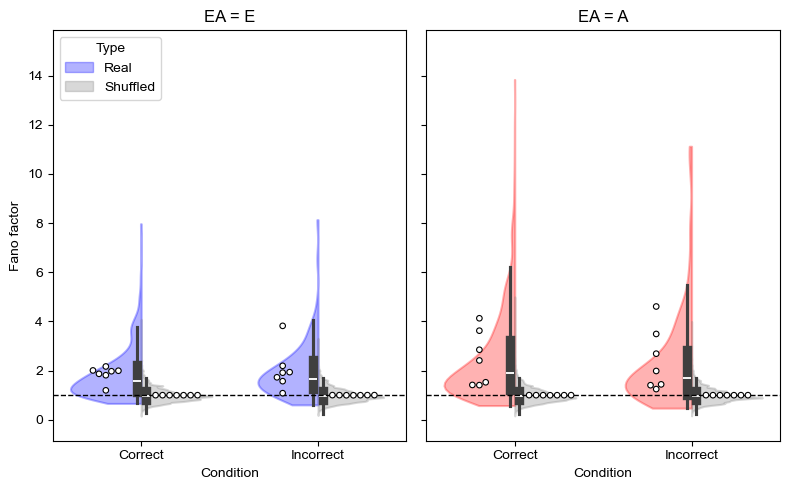

In [359]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch

df = df_all_animals_all_phases

rows = []

# ----------------------------
# Build long-format dataframe
# ----------------------------
for _, r in df.iterrows():
    
    cond = r["Correct/Incorrect"]
    ea = r["EA"]
    animal = r["Animal"]

    # REAL
    real = r["All_real_fano"]
    if not np.isnan(real):
        rows.append({
            "Fano": real,
            "Type": "Real",
            "Condition": cond,
            "EA": ea,
            "Animal": animal
        })

    # SHUFFLED
    shuffled = r["All_shuffled_fanos"]
    if isinstance(shuffled, (list, np.ndarray)) and len(shuffled) > 0:
        for v in shuffled:
            if not np.isnan(v):
                rows.append({
                    "Fano": v,
                    "Type": "Shuffled",
                    "Condition": cond,
                    "EA": ea,
                    "Animal": animal
                })

plot_df = pd.DataFrame(rows)

# ----------------------------
# FORCE CONDITION ORDER
# ----------------------------
order = ["Correct", "Incorrect"]

plot_df["Condition"] = pd.Categorical(
    plot_df["Condition"],
    categories=order,
    ordered=True
)

# ----------------------------
# Animal means for swarm
# ----------------------------
animal_df = (
    plot_df
    .groupby(["Animal", "Condition", "EA", "Type"])["Fano"]
    .mean()
    .reset_index()
)

animal_df["Condition"] = pd.Categorical(
    animal_df["Condition"],
    categories=order,
    ordered=True
)

# ----------------------------
# Y limits
# ----------------------------
ymin = plot_df["Fano"].min() - 1
ymax = plot_df["Fano"].max() + 2

# ----------------------------
# FIGURE
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

for i, (ax, ea) in enumerate(zip(axes, ["E", "A"])):

    sub = plot_df[plot_df["EA"] == ea]
    sub_an = animal_df[animal_df["EA"] == ea]

    # ----------------------------
    # VIOLIN
    # ----------------------------
    sns.violinplot(
        data=sub,
        x="Condition",
        y="Fano",
        hue="Type",
        split=True,
        inner="box",
        cut=0,
        linewidth=1.5,
        order=order,
        ax=ax
    )

    # ----------------------------
    # COLORS
    # ----------------------------
    ea_color = "blue" if ea == "E" else "red"
    shuffle_color = "grey"

    # ----------------------------
    # STYLE VIOLINS
    # ----------------------------
    for j, coll in enumerate(ax.collections):
        try:
            if j % 2 == 0:
                coll.set_facecolor(ea_color)
                coll.set_edgecolor(ea_color)
            else:
                coll.set_facecolor(shuffle_color)
                coll.set_edgecolor(shuffle_color)

            coll.set_alpha(0.3)
            coll.set_linewidth(1.5)
        except:
            pass

    # ----------------------------
    # SWARM (UNCHANGED)
    # ----------------------------
    sns.swarmplot(
        data=sub_an,
        x="Condition",
        y="Fano",
        hue="Type",
        dodge=True,
        palette=["white", "white"],
        edgecolor="black",
        linewidth=0.8,
        size=4,
        order=order,
        ax=ax
    )

    # ----------------------------
    # LINE
    # ----------------------------
    ax.axhline(1, linestyle="--", color="black", linewidth=1)

    ax.set_title(f"EA = {ea}")
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Condition")
    ax.set_ylabel("Fano factor")

    # ----------------------------
    # LEGEND (only first axis)
    # ----------------------------
    if i == 0:
        legend_elements = [
            Patch(facecolor=ea_color, edgecolor=ea_color, alpha=0.3, label="Real"),
            Patch(facecolor=shuffle_color, edgecolor=shuffle_color, alpha=0.3, label="Shuffled")
        ]
        ax.legend(handles=legend_elements, title="Type", loc="upper left")
    else:
        ax.legend_.remove()

# ----------------------------
# SAVE BEFORE SHOW
# ----------------------------
save_path = os.path.join(
    r'C:\Users\fgobbo\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Event times',
    "fano_violin_plot.svg"
)

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

In [360]:
import statsmodels.formula.api as smf
import statsmodels.stats.multicomp as mc

# ensure categorical types
plot_df["EA"] = plot_df["EA"].astype("category")
plot_df["Condition"] = plot_df["Condition"].astype("category")
plot_df["Type"] = plot_df["Type"].astype("category")
plot_df["Animal"] = plot_df["Animal"].astype("category")

# mixed model
model = smf.mixedlm(
    "Fano ~ EA*Condition + Type",
    data=plot_df,
    groups=plot_df["Animal"]
)

result = model.fit(method="lbfgs")

print(result.summary())

#------------------


results = []

for ea in plot_df["EA"].unique():

    sub = plot_df[plot_df["EA"] == ea].copy()

    # enforce categories
    sub["Type"] = sub["Type"].astype("category")

    if sub["Type"].nunique() < 2:
        results.append({
            "EA": ea,
            "Effect (Real - Shuffled)": None,
            "p-value": None,
            "note": "insufficient Type levels"
        })
        continue

    model = smf.mixedlm(
        "Fano ~ Type",
        data=sub,
        groups=sub["Animal"]
    )

    res = model.fit(method="lbfgs", reml=False)

    # safer way: search parameter name dynamically
    params = res.params
    pvals = res.pvalues

    type_effect = [k for k in params.index if "Type" in k]

    if len(type_effect) == 0:
        effect = None
        pval = None
    else:
        effect = params[type_effect[0]]
        pval = pvals[type_effect[0]]

    results.append({
        "EA": ea,
        "Effect (Real - Shuffled)": effect,
        "p-value": pval
    })

pd.DataFrame(results)



C:\Users\fgobbo\AppData\Roaming\Python\Python310\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


                   Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:      Fano        
No. Observations:       1229228       Method:                  REML        
No. Groups:             8             Scale:                   0.0953      
Min. group size:        75075         Log-Likelihood:          -299799.8665
Max. group size:        208208        Converged:               Yes         
Mean group size:        153653.5                                           
---------------------------------------------------------------------------
                               Coef.  Std.Err.    z     P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                       2.198    0.110   20.068 0.000  1.983  2.413
EA[T.E]                        -0.001    0.001   -1.851 0.064 -0.003  0.000
Condition[T.Incorrect]         -0.000    0.001   -0.379 0.705 -0.002  0.001
Type[T.Shuffled]               

C:\Users\fgobbo\AppData\Roaming\Python\Python310\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\fgobbo\AppData\Roaming\Python\Python310\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\fgobbo\AppData\Roaming\Python\Python310\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\fgobbo\AppData\Roaming\Python\Python310\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


,EA,Effect (Real - Shuffled),p-value
0,E,-0.879430,0.0
1,A,-1.475067,0.0


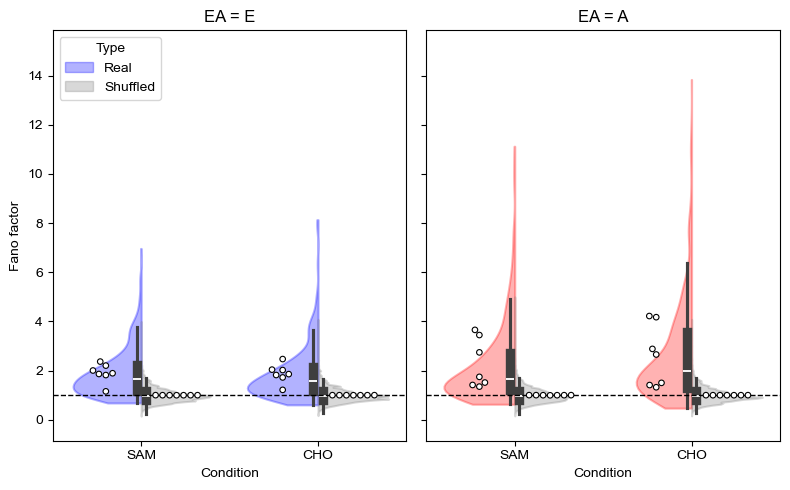

In [361]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch

df = df_all_animals_all_phases

rows = []

# ----------------------------
# Build long-format dataframe
# ----------------------------
for _, r in df.iterrows():
    
    cond = r["Stage"]
    ea = r["EA"]
    animal = r["Animal"]

    # REAL
    real = r["All_real_fano"]
    if not np.isnan(real):
        rows.append({
            "Fano": real,
            "Type": "Real",
            "Condition": cond,
            "EA": ea,
            "Animal": animal
        })

    # SHUFFLED
    shuffled = r["All_shuffled_fanos"]
    if isinstance(shuffled, (list, np.ndarray)) and len(shuffled) > 0:
        for v in shuffled:
            if not np.isnan(v):
                rows.append({
                    "Fano": v,
                    "Type": "Shuffled",
                    "Condition": cond,
                    "EA": ea,
                    "Animal": animal
                })

plot_df = pd.DataFrame(rows)

# ----------------------------
# FORCE ORDER: sam → cho
# ----------------------------
order = ["SAM", "CHO"]

plot_df["Condition"] = pd.Categorical(
    plot_df["Condition"],
    categories=order,
    ordered=True
)

# ----------------------------
# ANIMAL MEANS (for swarm)
# ----------------------------
animal_df = (
    plot_df
    .groupby(["Animal", "Condition", "EA", "Type"])["Fano"]
    .mean()
    .reset_index()
)

animal_df["Condition"] = pd.Categorical(
    animal_df["Condition"],
    categories=order,
    ordered=True
)

# ----------------------------
# SHARED Y LIMITS
# ----------------------------
ymin = plot_df["Fano"].min() - 1
ymax = plot_df["Fano"].max() + 2

# ----------------------------
# FIGURE
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

for i, (ax, ea) in enumerate(zip(axes, ["E", "A"])):

    sub = plot_df[plot_df["EA"] == ea]
    sub_an = animal_df[animal_df["EA"] == ea]

    # ----------------------------
    # VIOLIN
    # ----------------------------
    sns.violinplot(
        data=sub,
        x="Condition",
        y="Fano",
        hue="Type",
        split=True,
        inner="box",
        cut=0,
        linewidth=1.5,
        order=order,
        ax=ax
    )

    # ----------------------------
    # COLORS
    # ----------------------------
    ea_color = "blue" if ea == "E" else "red"
    shuffle_color = "grey"

    # ----------------------------
    # STYLE VIOLINS
    # ----------------------------
    for j, coll in enumerate(ax.collections):
        try:
            if j % 2 == 0:
                coll.set_facecolor(ea_color)
                coll.set_edgecolor(ea_color)
            else:
                coll.set_facecolor(shuffle_color)
                coll.set_edgecolor(shuffle_color)

            coll.set_alpha(0.3)
            coll.set_linewidth(1.5)
        except:
            pass

    # ----------------------------
    # SWARM (UNCHANGED)
    # ----------------------------
    sns.swarmplot(
        data=sub_an,
        x="Condition",
        y="Fano",
        hue="Type",
        dodge=True,
        palette=["white", "white"],
        edgecolor="black",
        linewidth=0.8,
        size=4,
        order=order,
        ax=ax
    )

    # ----------------------------
    # FANO = 1 LINE
    # ----------------------------
    ax.axhline(1, linestyle="--", color="black", linewidth=1)

    ax.set_title(f"EA = {ea}")
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Condition")
    ax.set_ylabel("Fano factor")

    # ----------------------------
    # LEGEND ONLY ON FIRST AXIS
    # ----------------------------
    if i == 0:
        legend_elements = [
            Patch(facecolor=ea_color, edgecolor=ea_color, alpha=0.3, label="Real"),
            Patch(facecolor=shuffle_color, edgecolor=shuffle_color, alpha=0.3, label="Shuffled")
        ]
        ax.legend(handles=legend_elements, title="Type", loc="upper left")
    else:
        ax.legend_.remove()

# ----------------------------
# SAVE BEFORE SHOW
# ----------------------------
save_path = os.path.join(
    r'C:\Users\fgobbo\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Event times',
    "fano_violin_plot_sam_cho.svg"
)

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

## Reward cell fano

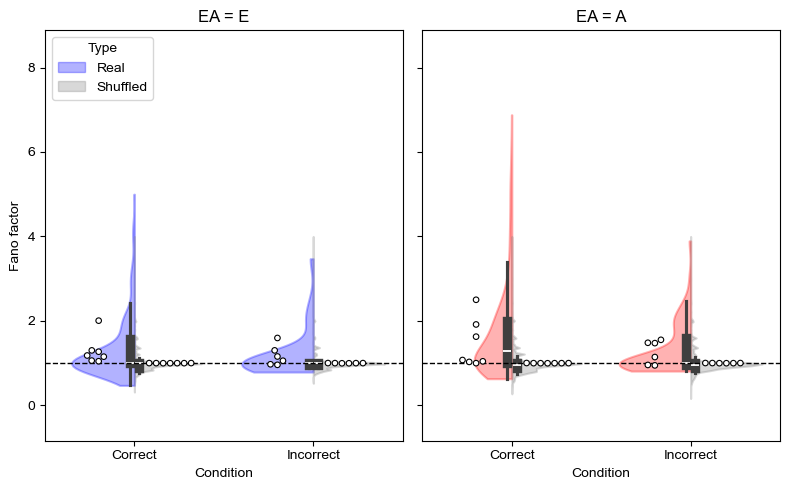

In [362]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch

df = df_all_animals_all_phases

rows = []

# ----------------------------
# Build long-format dataframe
# ----------------------------
for _, r in df.iterrows():
    
    cond = r["Correct/Incorrect"]
    ea = r["EA"]
    animal = r["Animal"]

    # REAL
    real = r["Reward_real_fano"]
    if not np.isnan(real):
        rows.append({
            "Fano": real,
            "Type": "Real",
            "Condition": cond,
            "EA": ea,
            "Animal": animal
        })

    # SHUFFLED
    shuffled = r["Reward_shuffled_fanos"]
    if isinstance(shuffled, (list, np.ndarray)) and len(shuffled) > 0:
        for v in shuffled:
            if not np.isnan(v):
                rows.append({
                    "Fano": v,
                    "Type": "Shuffled",
                    "Condition": cond,
                    "EA": ea,
                    "Animal": animal
                })

plot_df = pd.DataFrame(rows)

# ----------------------------
# FORCE CONDITION ORDER
# ----------------------------
order = ["Correct", "Incorrect"]

plot_df["Condition"] = pd.Categorical(
    plot_df["Condition"],
    categories=order,
    ordered=True
)

# ----------------------------
# Animal means for swarm
# ----------------------------
animal_df = (
    plot_df
    .groupby(["Animal", "Condition", "EA", "Type"])["Fano"]
    .mean()
    .reset_index()
)

animal_df["Condition"] = pd.Categorical(
    animal_df["Condition"],
    categories=order,
    ordered=True
)

# ----------------------------
# Y limits
# ----------------------------
ymin = plot_df["Fano"].min() - 1
ymax = plot_df["Fano"].max() + 2

# ----------------------------
# FIGURE
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

for i, (ax, ea) in enumerate(zip(axes, ["E", "A"])):

    sub = plot_df[plot_df["EA"] == ea]
    sub_an = animal_df[animal_df["EA"] == ea]

    # ----------------------------
    # VIOLIN
    # ----------------------------
    sns.violinplot(
        data=sub,
        x="Condition",
        y="Fano",
        hue="Type",
        split=True,
        inner="box",
        cut=0,
        linewidth=1.5,
        order=order,
        ax=ax
    )

    # ----------------------------
    # COLORS
    # ----------------------------
    ea_color = "blue" if ea == "E" else "red"
    shuffle_color = "grey"

    # ----------------------------
    # STYLE VIOLINS
    # ----------------------------
    for j, coll in enumerate(ax.collections):
        try:
            if j % 2 == 0:
                coll.set_facecolor(ea_color)
                coll.set_edgecolor(ea_color)
            else:
                coll.set_facecolor(shuffle_color)
                coll.set_edgecolor(shuffle_color)

            coll.set_alpha(0.3)
            coll.set_linewidth(1.5)
        except:
            pass

    # ----------------------------
    # SWARM (UNCHANGED)
    # ----------------------------
    sns.swarmplot(
        data=sub_an,
        x="Condition",
        y="Fano",
        hue="Type",
        dodge=True,
        palette=["white", "white"],
        edgecolor="black",
        linewidth=0.8,
        size=4,
        order=order,
        ax=ax
    )

    # ----------------------------
    # LINE
    # ----------------------------
    ax.axhline(1, linestyle="--", color="black", linewidth=1)

    ax.set_title(f"EA = {ea}")
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Condition")
    ax.set_ylabel("Fano factor")

    # ----------------------------
    # LEGEND (only first axis)
    # ----------------------------
    if i == 0:
        legend_elements = [
            Patch(facecolor=ea_color, edgecolor=ea_color, alpha=0.3, label="Real"),
            Patch(facecolor=shuffle_color, edgecolor=shuffle_color, alpha=0.3, label="Shuffled")
        ]
        ax.legend(handles=legend_elements, title="Type", loc="upper left")
    else:
        ax.legend_.remove()

# ----------------------------
# SAVE BEFORE SHOW
# ----------------------------
save_path = os.path.join(
    r'C:\Users\fgobbo\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Event times',
    "fano_violin_plot_reward_well.svg"
)

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

## First visited sw fano

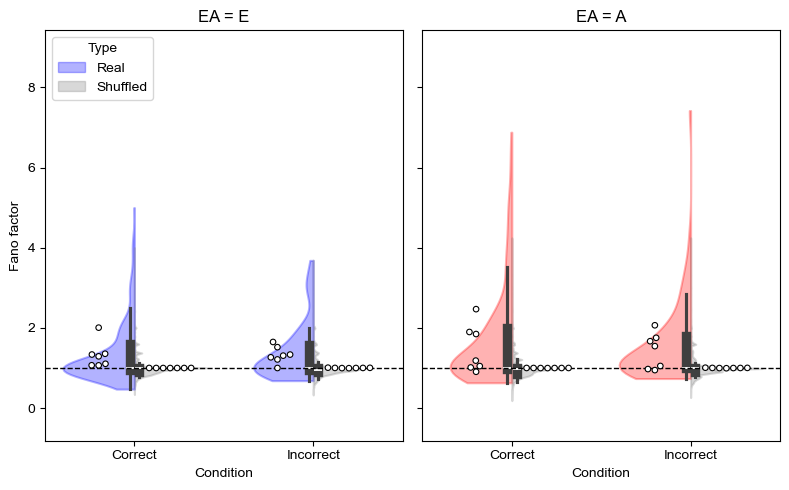

In [363]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch

df = df_all_animals_all_phases

rows = []

# ----------------------------
# Build long-format dataframe
# ----------------------------
for _, r in df.iterrows():
    
    cond = r["Correct/Incorrect"]
    ea = r["EA"]
    animal = r["Animal"]

    # REAL
    real = r["FirstVisit_real_fano"]
    if not np.isnan(real):
        rows.append({
            "Fano": real,
            "Type": "Real",
            "Condition": cond,
            "EA": ea,
            "Animal": animal
        })

    # SHUFFLED
    shuffled = r["FirstVisit_shuffled_fanos"]
    if isinstance(shuffled, (list, np.ndarray)) and len(shuffled) > 0:
        for v in shuffled:
            if not np.isnan(v):
                rows.append({
                    "Fano": v,
                    "Type": "Shuffled",
                    "Condition": cond,
                    "EA": ea,
                    "Animal": animal
                })

plot_df = pd.DataFrame(rows)

# ----------------------------
# FORCE CONDITION ORDER
# ----------------------------
order = ["Correct", "Incorrect"]

plot_df["Condition"] = pd.Categorical(
    plot_df["Condition"],
    categories=order,
    ordered=True
)

# ----------------------------
# Animal means for swarm
# ----------------------------
animal_df = (
    plot_df
    .groupby(["Animal", "Condition", "EA", "Type"])["Fano"]
    .mean()
    .reset_index()
)

animal_df["Condition"] = pd.Categorical(
    animal_df["Condition"],
    categories=order,
    ordered=True
)

# ----------------------------
# Y limits
# ----------------------------
ymin = plot_df["Fano"].min() - 1
ymax = plot_df["Fano"].max() + 2

# ----------------------------
# FIGURE
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

for i, (ax, ea) in enumerate(zip(axes, ["E", "A"])):

    sub = plot_df[plot_df["EA"] == ea]
    sub_an = animal_df[animal_df["EA"] == ea]

    # ----------------------------
    # VIOLIN
    # ----------------------------
    sns.violinplot(
        data=sub,
        x="Condition",
        y="Fano",
        hue="Type",
        split=True,
        inner="box",
        cut=0,
        linewidth=1.5,
        order=order,
        ax=ax
    )

    # ----------------------------
    # COLORS
    # ----------------------------
    ea_color = "blue" if ea == "E" else "red"
    shuffle_color = "grey"

    # ----------------------------
    # STYLE VIOLINS
    # ----------------------------
    for j, coll in enumerate(ax.collections):
        try:
            if j % 2 == 0:
                coll.set_facecolor(ea_color)
                coll.set_edgecolor(ea_color)
            else:
                coll.set_facecolor(shuffle_color)
                coll.set_edgecolor(shuffle_color)

            coll.set_alpha(0.3)
            coll.set_linewidth(1.5)
        except:
            pass

    # ----------------------------
    # SWARM (UNCHANGED)
    # ----------------------------
    sns.swarmplot(
        data=sub_an,
        x="Condition",
        y="Fano",
        hue="Type",
        dodge=True,
        palette=["white", "white"],
        edgecolor="black",
        linewidth=0.8,
        size=4,
        order=order,
        ax=ax
    )

    # ----------------------------
    # LINE
    # ----------------------------
    ax.axhline(1, linestyle="--", color="black", linewidth=1)

    ax.set_title(f"EA = {ea}")
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Condition")
    ax.set_ylabel("Fano factor")

    # ----------------------------
    # LEGEND (only first axis)
    # ----------------------------
    if i == 0:
        legend_elements = [
            Patch(facecolor=ea_color, edgecolor=ea_color, alpha=0.3, label="Real"),
            Patch(facecolor=shuffle_color, edgecolor=shuffle_color, alpha=0.3, label="Shuffled")
        ]
        ax.legend(handles=legend_elements, title="Type", loc="upper left")
    else:
        ax.legend_.remove()

# ----------------------------
# SAVE BEFORE SHOW
# ----------------------------
save_path = os.path.join(
    r'C:\Users\fgobbo\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Event times',
    "fano_violin_plot_first_well.svg"
)

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

In [365]:
df_all_animals_all_phases.All_real_isis

0                         [0.2, 6.8500000000000005, 1.55]
1       [0.1, 0.05, 0.8, 1.2000000000000002, 0.05, 0.0...
2       [0.1, 0.30000000000000004, 0.15000000000000002...
3       [0.1, 0.05, 0.6000000000000001, 0.1, 0.9500000...
4       [0.30000000000000004, 0.65, 0.25, 0.9500000000...
                              ...                        
1243    [1.6, 0.15000000000000002, 0.25, 0.4, 1.6, 0.4...
1244    [2.75, 0.15000000000000002, 0.2, 0.15000000000...
1245                                               [0.05]
1246    [0.35000000000000003, 5.15, 0.3000000000000000...
1247                                                   []
Name: All_real_isis, Length: 1248, dtype: object

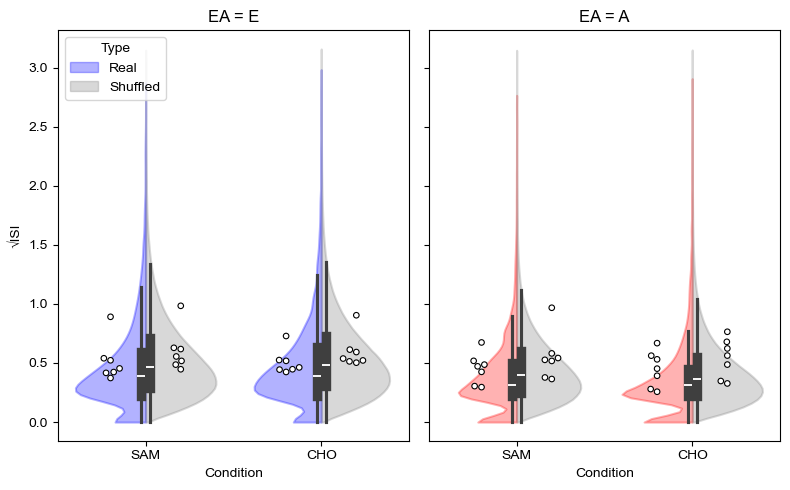

In [368]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch

df = df_all_animals_all_phases

rows = []

# ----------------------------
# Safe flatten helper
# ----------------------------
def safe_iter(x):
    if isinstance(x, (list, np.ndarray)):
        return np.ravel(x)
    return np.array([x])

# ----------------------------
# Build long-format dataframe (ISI)
# ----------------------------
for _, r in df.iterrows():
    
    cond = r["Stage"]
    ea = r["EA"]
    animal = r["Animal"]

    # REAL ISI
    real_arr = r["All_real_isis"]

    for v in safe_iter(real_arr):
        if not np.isnan(v):
            rows.append({
                "ISI": v,
                "Type": "Real",
                "Condition": cond,
                "EA": ea,
                "Animal": animal
            })

    # SHUFFLED ISI
    shuffled_arr = r["All_shuffled_isis"]

    for v in safe_iter(shuffled_arr):
        if not np.isnan(v):
            rows.append({
                "ISI": v,
                "Type": "Shuffled",
                "Condition": cond,
                "EA": ea,
                "Animal": animal
            })

plot_df = pd.DataFrame(rows)

# ----------------------------
# REMOVE INVALID VALUES (needed for sqrt too)
# ----------------------------
plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
plot_df = plot_df.dropna(subset=["ISI"])
plot_df = plot_df[plot_df["ISI"] >= 0]

# ----------------------------
# APPLY SQRT TRANSFORM
# ----------------------------
plot_df["ISI_sqrt"] = np.sqrt(plot_df["ISI"])

# ----------------------------
# ORDER
# ----------------------------
order = ["SAM", "CHO"]

plot_df["Condition"] = pd.Categorical(
    plot_df["Condition"],
    categories=order,
    ordered=True
)

# ----------------------------
# ANIMAL MEANS
# ----------------------------
animal_df = (
    plot_df
    .groupby(["Animal", "Condition", "EA", "Type"])["ISI_sqrt"]
    .mean()
    .reset_index()
)

animal_df["Condition"] = pd.Categorical(
    animal_df["Condition"],
    categories=order,
    ordered=True
)

# ----------------------------
# Y LIMITS
# ----------------------------
ymin = plot_df["ISI_sqrt"].min()
ymax = plot_df["ISI_sqrt"].max()

# ----------------------------
# FIGURE
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

for i, (ax, ea) in enumerate(zip(axes, ["E", "A"])):

    sub = plot_df[plot_df["EA"] == ea]
    sub_an = animal_df[animal_df["EA"] == ea]

    # ----------------------------
    # VIOLIN
    # ----------------------------
    sns.violinplot(
        data=sub,
        x="Condition",
        y="ISI_sqrt",
        hue="Type",
        split=True,
        inner="box",
        cut=0,
        linewidth=1.5,
        order=order,
        ax=ax
    )

    # ----------------------------
    # COLORS
    # ----------------------------
    ea_color = "blue" if ea == "E" else "red"
    shuffle_color = "grey"

    # ----------------------------
    # STYLE VIOLINS
    # ----------------------------
    for j, coll in enumerate(ax.collections):
        try:
            if j % 2 == 0:
                coll.set_facecolor(ea_color)
                coll.set_edgecolor(ea_color)
            else:
                coll.set_facecolor(shuffle_color)
                coll.set_edgecolor(shuffle_color)

            coll.set_alpha(0.3)
            coll.set_linewidth(1.5)
        except:
            pass

    # ----------------------------
    # SWARM (UNCHANGED)
    # ----------------------------
    sns.swarmplot(
        data=sub_an,
        x="Condition",
        y="ISI_sqrt",
        hue="Type",
        dodge=True,
        palette=["white", "white"],
        edgecolor="black",
        linewidth=0.8,
        size=4,
        order=order,
        ax=ax
    )

    ax.set_title(f"EA = {ea}")
    ax.set_xlabel("Condition")
    ax.set_ylabel("√ISI")

    # ----------------------------
    # LEGEND ONLY ON FIRST AXIS
    # ----------------------------
    if i == 0:
        legend_elements = [
            Patch(facecolor=ea_color, edgecolor=ea_color, alpha=0.3, label="Real"),
            Patch(facecolor=shuffle_color, edgecolor=shuffle_color, alpha=0.3, label="Shuffled")
        ]
        ax.legend(handles=legend_elements, title="Type", loc="upper left")
    else:
        ax.legend_.remove()

# ----------------------------
# SAVE
# ----------------------------
save_path = os.path.join(
    r'C:\Users\fgobbo\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Event times',
    "isi_violin_plot_sam_cho_sqrt.svg"
)

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

In [373]:
df_all_animals_all_phases.columns

Index(['Trial_row', 'Animal', 'Rewarded well', 'Trial', 'Trial Status',
       'Session', 'Recording', 'Stage', 'EA', 'Correct/Incorrect', 'Direct',
       'Start Box', 'Reward well', 'Path', 'First_visited_SW',
       'All_cells_event_times', 'Reward_cells_event_times',
       'First_visit_cells_event_times', 'All_real_fano', 'All_shuffled_fanos',
       'All_fano_p', 'All_real_cv', 'All_shuffled_cvs', 'All_isi_p',
       'All_real_isis', 'All_shuffled_isis', 'Reward_real_fano',
       'Reward_shuffled_fanos', 'Reward_fano_p', 'Reward_real_cv',
       'Reward_shuffled_cvs', 'Reward_isi_p', 'Reward_real_isis',
       'Reward_shuffled_isis', 'FirstVisit_real_fano',
       'FirstVisit_shuffled_fanos', 'FirstVisit_fano_p', 'FirstVisit_real_cv',
       'FirstVisit_shuffled_cvs', 'FirstVisit_isi_p', 'FirstVisit_real_isis',
       'FirstVisit_shuffled_isis'],
      dtype='object')

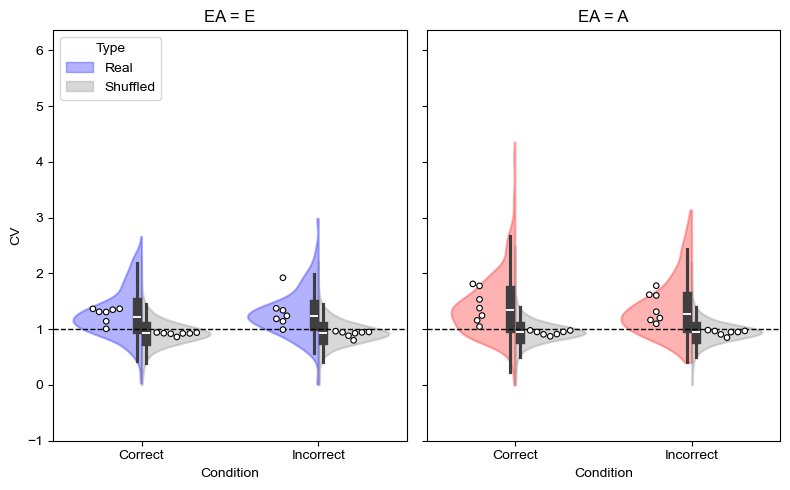

In [377]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch

df = df_all_animals_all_phases

rows = []

# ----------------------------
# Build long-format dataframe
# ----------------------------
for _, r in df.iterrows():
    
    cond = r["Correct/Incorrect"]
    ea = r["EA"]
    animal = r["Animal"]

    # REAL
    real = r["All_real_cv"]
    if not np.isnan(real):
        rows.append({
            "Fano": real,
            "Type": "Real",
            "Condition": cond,
            "EA": ea,
            "Animal": animal
        })

    # SHUFFLED
    shuffled = r["All_shuffled_cvs"]
    if isinstance(shuffled, (list, np.ndarray)) and len(shuffled) > 0:
        for v in shuffled:
            if not np.isnan(v):
                rows.append({
                    "Fano": v,
                    "Type": "Shuffled",
                    "Condition": cond,
                    "EA": ea,
                    "Animal": animal
                })

plot_df = pd.DataFrame(rows)

# ----------------------------
# FORCE CONDITION ORDER
# ----------------------------
order = ["Correct", "Incorrect"]

plot_df["Condition"] = pd.Categorical(
    plot_df["Condition"],
    categories=order,
    ordered=True
)

# ----------------------------
# Animal means for swarm
# ----------------------------
animal_df = (
    plot_df
    .groupby(["Animal", "Condition", "EA", "Type"])["Fano"]
    .mean()
    .reset_index()
)

animal_df["Condition"] = pd.Categorical(
    animal_df["Condition"],
    categories=order,
    ordered=True
)

# ----------------------------
# Y limits
# ----------------------------
ymin = plot_df["Fano"].min() - 1
ymax = plot_df["Fano"].max() + 2

# ----------------------------
# FIGURE
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

for i, (ax, ea) in enumerate(zip(axes, ["E", "A"])):

    sub = plot_df[plot_df["EA"] == ea]
    sub_an = animal_df[animal_df["EA"] == ea]

    # ----------------------------
    # VIOLIN
    # ----------------------------
    sns.violinplot(
        data=sub,
        x="Condition",
        y="Fano",
        hue="Type",
        split=True,
        inner="box",
        cut=0,
        linewidth=1.5,
        order=order,
        ax=ax
    )

    # ----------------------------
    # COLORS
    # ----------------------------
    ea_color = "blue" if ea == "E" else "red"
    shuffle_color = "grey"

    # ----------------------------
    # STYLE VIOLINS
    # ----------------------------
    for j, coll in enumerate(ax.collections):
        try:
            if j % 2 == 0:
                coll.set_facecolor(ea_color)
                coll.set_edgecolor(ea_color)
            else:
                coll.set_facecolor(shuffle_color)
                coll.set_edgecolor(shuffle_color)

            coll.set_alpha(0.3)
            coll.set_linewidth(1.5)
        except:
            pass

    # ----------------------------
    # SWARM (UNCHANGED)
    # ----------------------------
    sns.swarmplot(
        data=sub_an,
        x="Condition",
        y="Fano",
        hue="Type",
        dodge=True,
        palette=["white", "white"],
        edgecolor="black",
        linewidth=0.8,
        size=4,
        order=order,
        ax=ax
    )

    # ----------------------------
    # LINE
    # ----------------------------
    ax.axhline(1, linestyle="--", color="black", linewidth=1)

    ax.set_title(f"EA = {ea}")
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Condition")
    ax.set_ylabel("CV")

    # ----------------------------
    # LEGEND (only first axis)
    # ----------------------------
    if i == 0:
        legend_elements = [
            Patch(facecolor=ea_color, edgecolor=ea_color, alpha=0.3, label="Real"),
            Patch(facecolor=shuffle_color, edgecolor=shuffle_color, alpha=0.3, label="Shuffled")
        ]
        ax.legend(handles=legend_elements, title="Type", loc="upper left")
    else:
        ax.legend_.remove()

# ----------------------------
# SAVE BEFORE SHOW
# ----------------------------
save_path = os.path.join(
    r'C:\Users\fgobbo\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Event times',
    "cv_violin_plot.svg"
)

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ISI HISTOGRAM

def isi_analysis(spike_times, bins=50):
    spike_times = np.sort(spike_times)
    isis = np.diff(spike_times)
    
    plt.figure()
    plt.hist(isis, bins=bins)
    plt.xlabel("Inter-spike interval (s)")
    plt.ylabel("Count")
    plt.title("ISI Histogram")
    plt.show()
    
    return isis

# Example usage
isis = isi_analysis(spike_times)

In [ ]:
# Shuffke ctrl
def shuffle_control(spike_times, t_start=0, t_end=10, bin_size=0.01, n_shuffles=1000):
    n_spikes = len(spike_times)
    
    shuffled_fanos = []
    
    for _ in range(n_shuffles):
        # Generate random spike times (Poisson-like null)
        shuffled = np.random.uniform(t_start, t_end, n_spikes)
        
        fano, _ = fano_factor(shuffled, t_start, t_end, bin_size)
        shuffled_fanos.append(fano)
    
    return np.array(shuffled_fanos)

# Run shuffle test
real_fano, _ = fano_factor(spike_times)
shuffled_fanos = shuffle_control(spike_times)

# Plot comparison
plt.figure()
plt.hist(shuffled_fanos, bins=30, alpha=0.7, label="Shuffled")
plt.axvline(real_fano, linestyle='dashed', linewidth=2, label="Real")
plt.xlabel("Fano factor")
plt.ylabel("Count")
plt.legend()
plt.title("Shuffle Control")
plt.show()

# p-value (how extreme is real vs null)
p_value = np.mean(shuffled_fanos >= real_fano)
print("p-value:", p_value)

How to interpret results
Fano ≈ 1 → random (Poisson-like)
Fano > 1 + significant p-value → clustering / synchrony
ISI skewed to small values → bursts
Real Fano outside shuffle distribution → not by chance

spike_times = np.array([120, 370, 510, 1030]) in ms

or 

spike_train = np.array([0,0,1,0,1,0,0,1])
dt = 0.001  # 1 ms resolution

spike_times = np.where(spike_train == 1)[0] * dt     this for one cell, then concat them and sort small to big

In [2]:
p_value

NameError: name 'p_value' is not defined